<a href="https://colab.research.google.com/github/Kunjan1504/DA/blob/main/Customer_Segmentation_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating synthetic customer data...
   CustomerID Gender  Age  AnnualIncome_USD  SpendingScore
0         425  Other   65             84920             25
1         553   Male   25             29832             67
2         149  Other   30            102192             79
3         372   Male   50            123740             31
4         386   Male   48            119281             11

--- Preprocessing Data ---

--- Finding Optimal Clusters (Elbow Method) ---
Saved Elbow Curve to 'elbow_curve.png'.


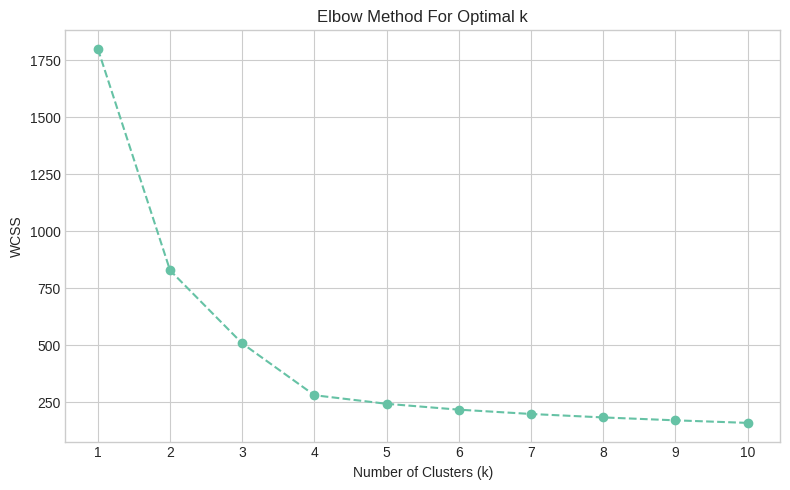


--- Applying K-Means Clustering (k=4) ---

--- Segment Analysis & Visualization ---

Cluster Summary (Averages):
          Age  AnnualIncome_USD  SpendingScore  CustomerCount
Cluster                                                      
0        55.4          104071.3           24.5            141
1        25.3           35596.7           74.9            157
2        44.6           40810.2           31.1            155
3        27.1           91826.3           84.9            147


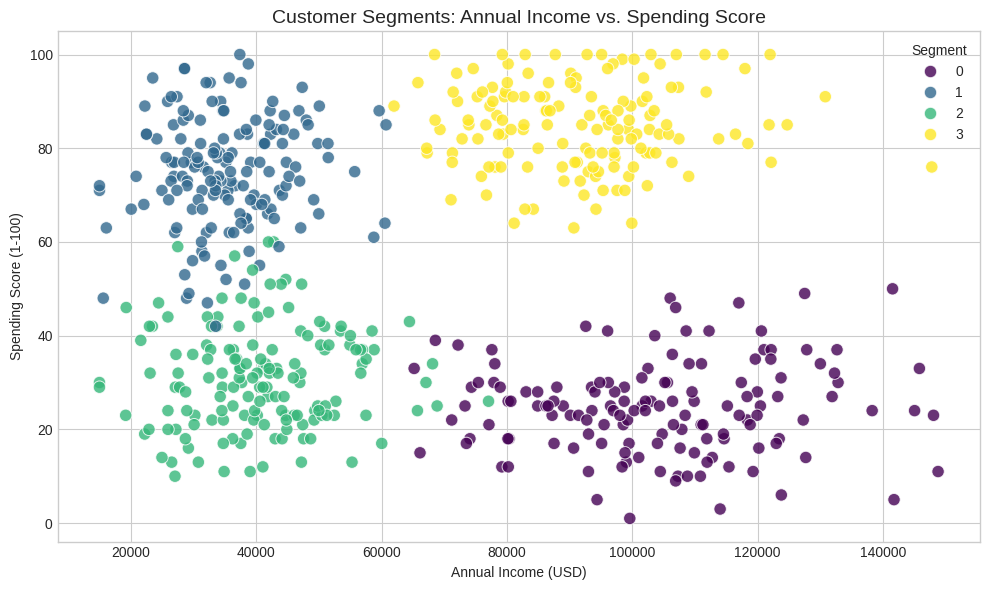

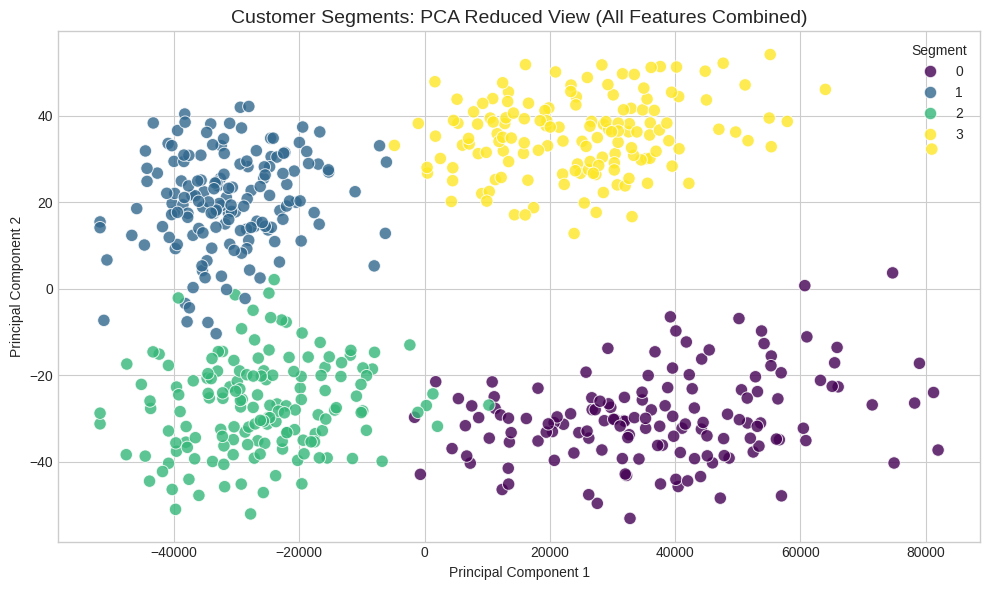

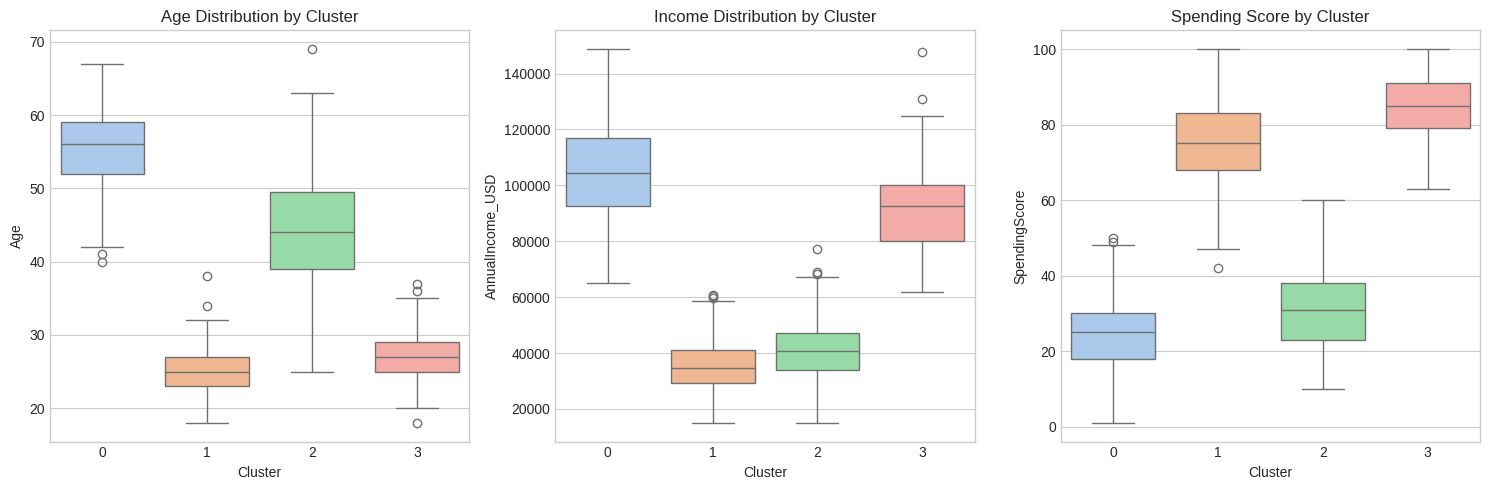


Project execution complete! Review the generated plots and summary statistics to define your targeted insights.


In [1]:
"""
Customer Segmentation Project using K-Means Clustering
------------------------------------------------------
This script generates a realistic mock customer dataset, preprocesses the data,
determines the optimal number of clusters using the Elbow Method, applies K-Means
clustering, and visualizes the customer segments.

Requirements: pandas, numpy, matplotlib, seaborn, scikit-learn
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

def generate_mock_data(n_customers=500):
    """
    Generates synthetic customer data with distinct behavioral clusters
    to simulate a real-world retail or e-commerce dataset.
    """
    np.random.seed(42)

    # Define 4 customer archetypes to ensure meaningful clustering

    # Group 1: Young, High Income, High Spenders (Target: Premium / Trend)
    g1_age = np.random.normal(28, 4, int(n_customers * 0.25))
    g1_income = np.random.normal(90000, 15000, int(n_customers * 0.25))
    g1_spend = np.random.normal(85, 10, int(n_customers * 0.25))

    # Group 2: Middle-aged, Low Income, Low Spenders (Target: Budget / Essentials)
    g2_age = np.random.normal(45, 8, int(n_customers * 0.25))
    g2_income = np.random.normal(40000, 10000, int(n_customers * 0.25))
    g2_spend = np.random.normal(30, 12, int(n_customers * 0.25))

    # Group 3: Older, High Income, Low Spenders (Target: High-value, low frequency)
    g3_age = np.random.normal(55, 6, int(n_customers * 0.25))
    g3_income = np.random.normal(100000, 20000, int(n_customers * 0.25))
    g3_spend = np.random.normal(25, 10, int(n_customers * 0.25))

    # Group 4: Young, Low Income, High Spenders (Target: Flash sales, credit)
    g4_age = np.random.normal(25, 3, int(n_customers * 0.25))
    g4_income = np.random.normal(35000, 8000, int(n_customers * 0.25))
    g4_spend = np.random.normal(75, 12, int(n_customers * 0.25))

    # Combine the groups
    ages = np.concatenate([g1_age, g2_age, g3_age, g4_age])
    incomes = np.concatenate([g1_income, g2_income, g3_income, g4_income])
    spends = np.concatenate([g1_spend, g2_spend, g3_spend, g4_spend])

    # Keep values within realistic bounds (e.g., Spending Score 1-100)
    ages = np.clip(ages, 18, 80).astype(int)
    incomes = np.clip(incomes, 15000, 150000).astype(int)
    spends = np.clip(spends, 1, 100).astype(int)

    # Randomly assign genders
    genders = np.random.choice(['Male', 'Female', 'Other'], size=n_customers, p=[0.48, 0.48, 0.04])

    # Create DataFrame
    df = pd.DataFrame({
        'CustomerID': range(1, n_customers + 1),
        'Gender': genders,
        'Age': ages,
        'AnnualIncome_USD': incomes,
        'SpendingScore': spends
    })

    # Shuffle the dataset
    df = df.sample(frac=1).reset_index(drop=True)
    return df

def preprocess_data(df):
    """
    Prepares the data for clustering by encoding categoricals and scaling numericals.
    """
    print("\n--- Preprocessing Data ---")

    # We will cluster based on Age, Annual Income, and Spending Score
    features = ['Age', 'AnnualIncome_USD', 'SpendingScore']
    X = df[features]

    # Standardize the features (Mean=0, Variance=1)
    # This is crucial for distance-based algorithms like K-Means
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X, X_scaled, scaler, features

def find_optimal_clusters(X_scaled):
    """
    Uses the Elbow Method to find the optimal number of clusters (K).
    """
    print("\n--- Finding Optimal Clusters (Elbow Method) ---")
    wcss = [] # Within-Cluster-Sum-of-Squares

    # Test 1 to 10 clusters
    k_range = range(1, 11)
    for i in k_range:
        kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)

    # Plot the Elbow Curve
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, wcss, marker='o', linestyle='--')
    plt.title('Elbow Method For Optimal k')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS')
    plt.xticks(k_range)
    plt.tight_layout()
    plt.savefig('elbow_curve.png')
    print("Saved Elbow Curve to 'elbow_curve.png'.")
    plt.show()

def perform_clustering(df, X_scaled, n_clusters=4):
    """
    Applies K-Means clustering and attaches the labels back to the dataframe.
    """
    print(f"\n--- Applying K-Means Clustering (k={n_clusters}) ---")
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Add cluster labels to the original dataframe
    df['Cluster'] = cluster_labels
    return df, kmeans

def analyze_and_visualize(df):
    """
    Analyzes the segments and generates visualizations.
    """
    print("\n--- Segment Analysis & Visualization ---")

    # 1. Summary Statistics per Cluster
    cluster_summary = df.groupby('Cluster')[['Age', 'AnnualIncome_USD', 'SpendingScore']].mean().round(1)
    cluster_summary['CustomerCount'] = df.groupby('Cluster').size()
    print("\nCluster Summary (Averages):")
    print(cluster_summary)

    # 2. Scatter Plot: Income vs Spending Score
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='AnnualIncome_USD',
        y='SpendingScore',
        hue='Cluster',
        palette='viridis',
        data=df,
        s=80,
        alpha=0.8
    )
    plt.title('Customer Segments: Annual Income vs. Spending Score', fontsize=14)
    plt.xlabel('Annual Income (USD)')
    plt.ylabel('Spending Score (1-100)')
    plt.legend(title='Segment')
    plt.tight_layout()
    plt.savefig('income_vs_spending.png')
    plt.show()

    # 3. 3D Visualization using PCA (Reducing 3 features to 2 components for plotting)
    pca = PCA(n_components=2)
    components = pca.fit_transform(df[['Age', 'AnnualIncome_USD', 'SpendingScore']])

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=components[:, 0],
        y=components[:, 1],
        hue=df['Cluster'],
        palette='viridis',
        s=80,
        alpha=0.8
    )
    plt.title('Customer Segments: PCA Reduced View (All Features Combined)', fontsize=14)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Segment')
    plt.tight_layout()
    plt.savefig('pca_clusters.png')
    plt.show()

    # 4. Boxplots for Demographic Analysis
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sns.boxplot(x='Cluster', y='Age', data=df, ax=axes[0], palette='pastel')
    axes[0].set_title('Age Distribution by Cluster')

    sns.boxplot(x='Cluster', y='AnnualIncome_USD', data=df, ax=axes[1], palette='pastel')
    axes[1].set_title('Income Distribution by Cluster')

    sns.boxplot(x='Cluster', y='SpendingScore', data=df, ax=axes[2], palette='pastel')
    axes[2].set_title('Spending Score by Cluster')

    plt.tight_layout()
    plt.savefig('cluster_demographics.png')
    plt.show()

def main():
    # 1. Generate Data
    print("Generating synthetic customer data...")
    df = generate_mock_data(n_customers=600)
    print(df.head())

    # 2. Preprocess Data
    X, X_scaled, scaler, features = preprocess_data(df)

    # 3. Find Optimal Clusters
    # Note: Look at the generated 'elbow_curve.png' to visually confirm the elbow.
    # Given how we generated the data, it should strongly point to k=4.
    find_optimal_clusters(X_scaled)

    # 4. Perform Clustering
    df_clustered, kmeans_model = perform_clustering(df, X_scaled, n_clusters=4)

    # 5. Analyze and Visualize Results
    analyze_and_visualize(df_clustered)

    print("\nProject execution complete! Review the generated plots and summary statistics to define your targeted insights.")

if __name__ == "__main__":
    main()